In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from datasets.wmh import WMH
from datasets.dbb import DBB
from datasets.atlas import ATLAS
from collections import Counter

In [3]:
DBB_DATASET_FOLDER = "/run/media/gianluca/Hard drive/DBB"
WMH_DATASET_FOLDER = "/run/media/gianluca/Hard drive/WMH"
ATLAS_PREPROCESSED_DATASET_FOLDER = "/run/media/gianluca/Hard drive/ATLAS_R3.0_preprocessed"

# ATLAS 3.0

In [4]:
df = ATLAS.get_metadata(ATLAS_PREPROCESSED_DATASET_FOLDER)
df.head(5)

,SESSION ID,DATASET,DAYS POST STROKE,CHRONICITY,SITE,T1W FILEPATH,SEGMENTATION FILEPATH
0,sub-r001s001_ses-1,Training,471.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s001...,ATLAS3_Training_Preprocessed/R001/sub-r001s001...
1,sub-r001s002_ses-1,Training,669.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s002...,ATLAS3_Training_Preprocessed/R001/sub-r001s002...
2,sub-r001s003_ses-1,Training,709.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s003...,ATLAS3_Training_Preprocessed/R001/sub-r001s003...
3,sub-r001s004_ses-1,Training,871.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s004...,ATLAS3_Training_Preprocessed/R001/sub-r001s004...
4,sub-r001s005_ses-1,Training,1917.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s005...,ATLAS3_Training_Preprocessed/R001/sub-r001s005...


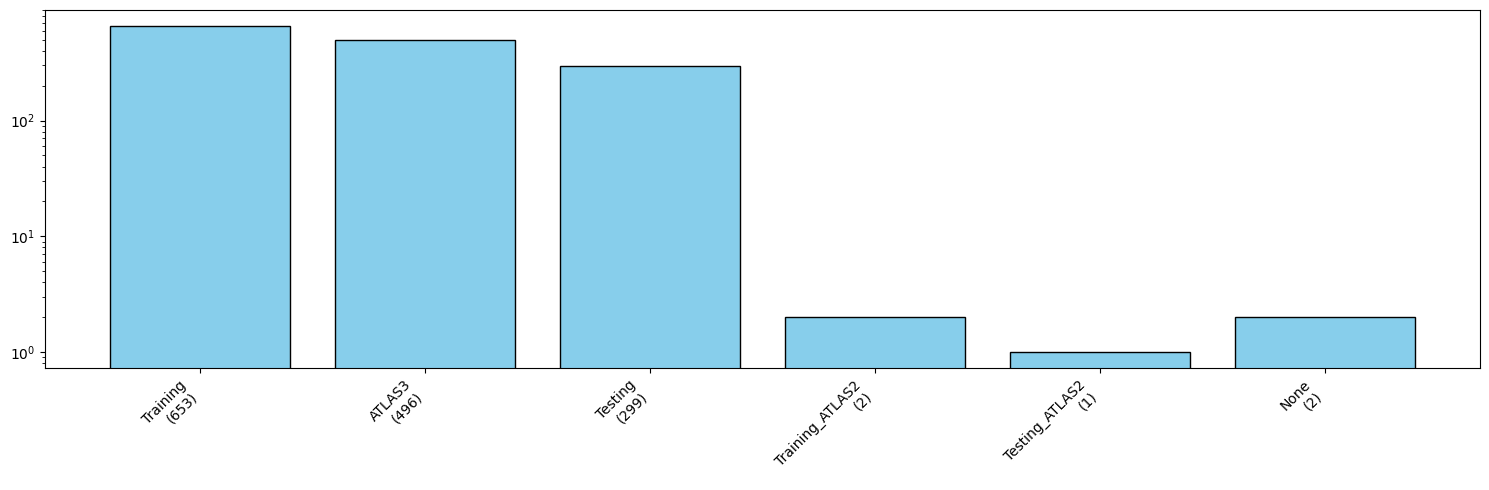

In [5]:
counts = Counter(df["DATASET"])
keys = [f"{key}\n({value})" if key is not None else f"None\n({value})" for key, value in counts.items()]

fig, ax = plt.subplots(figsize=(15,5))
ax.bar(keys, counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

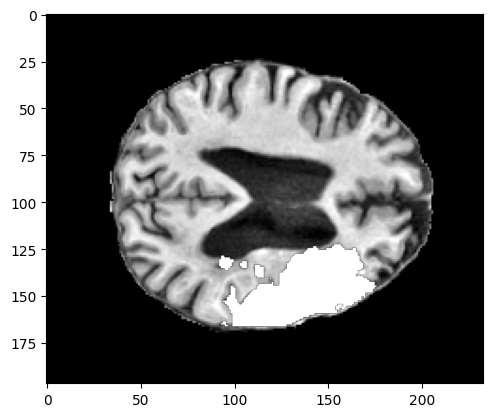

In [13]:
row = df.iloc()[0]

t1w_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}")
mask_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['SEGMENTATION FILEPATH']}")

plt.imshow(t1w_nib.get_fdata()[:,:,100], cmap=plt.cm.gray)
plt.imshow(mask_nib.get_fdata()[:,:,100], alpha=(mask_nib.get_fdata()[:,:,100]>0).astype(float), cmap=plt.cm.gray)

## Compare available resolutions

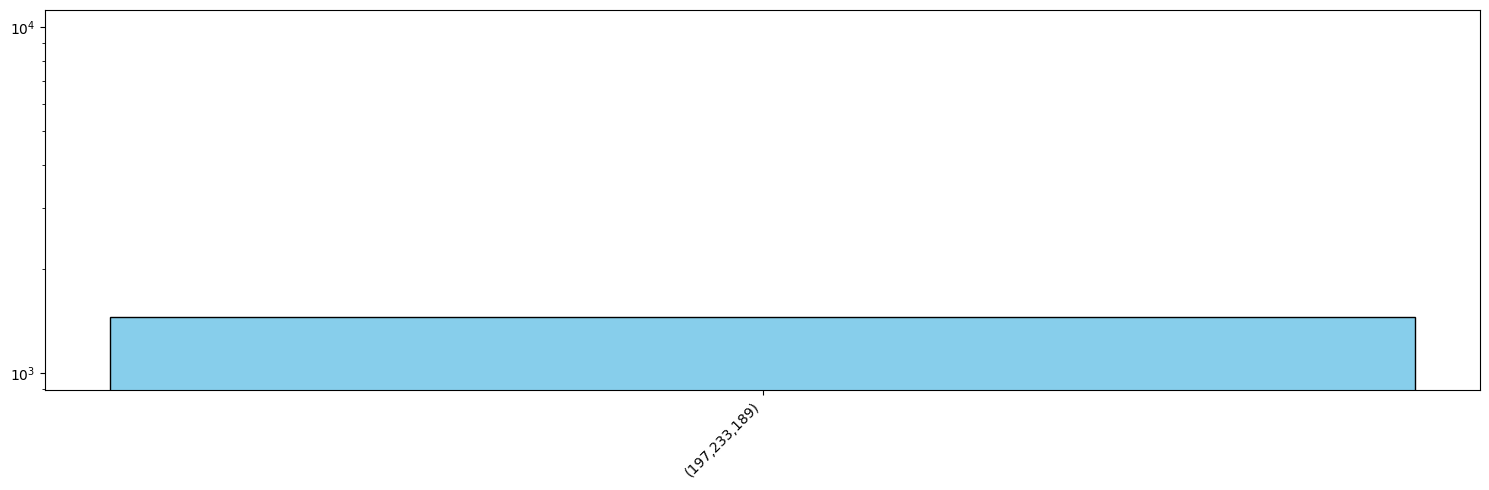

In [6]:
shapes = [
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").shape
    for t1w_filepath in df["T1W FILEPATH"]
]


counts = Counter(shapes)

fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [10]:
voxel_sizes = np.array([
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").header.get_zooms()
    for t1w_filepath in df["T1W FILEPATH"]
])

t1_x_mean, t1_x_std = np.mean(voxel_sizes[:,0]), np.std(voxel_sizes[:,0])
t1_y_mean, t1_y_std = np.mean(voxel_sizes[:,1]), np.std(voxel_sizes[:,1])
t1_z_mean, t1_z_std = np.mean(voxel_sizes[:,2]), np.std(voxel_sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.00, 1.00±0.00)


## Orientation

In [11]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").affine))
    for t1w_filepath in df["T1W FILEPATH"]
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['RAS'], dtype='<U3'), counts=array([1453]))


# Distorted Brain Benchmark (DBB)

In [4]:
df = DBB.get_patients_metadata(DBB_DATASET_FOLDER)
scans_filepath = DBB.get_scans_filepath(DBB_DATASET_FOLDER) 

df.head()

,SUBJECT,ORIGINAL_ID,AGE,GENDER,SOURCE,CATEGORY,SET,ORIGINAL_FILENAME,MRI SEQUENCE,STATIC MAGNETIC FIELD,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE,AFFINE MATRIX FILE
0,0001,IRC04H_00F004_F_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F004_F_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
1,0002,IRC04H_00F011_P_1,0.08,F,C-MIND,Healthy,train,IRC04H_00F011_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
2,0003,IRC04H_00F020_P_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F020_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
3,0004,IRC04H_00F031_P_1,0.71,F,C-MIND,Healthy,train,IRC04H_00F031_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
4,0005,IRC04H_00F032_P_1,0.11,F,C-MIND,Healthy,train,IRC04H_00F032_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES


In [5]:
df[["T1-W FILE", "SEGMENTATION FILE", "BRAIN MASK FILE", "RAW BRAIN MASK FILE"]].describe()

,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE
count,955,955,955,955
unique,2,1,1,2
top,NO,YES,YES,YES
freq,711,955,955,711


## Compare the available resolutions

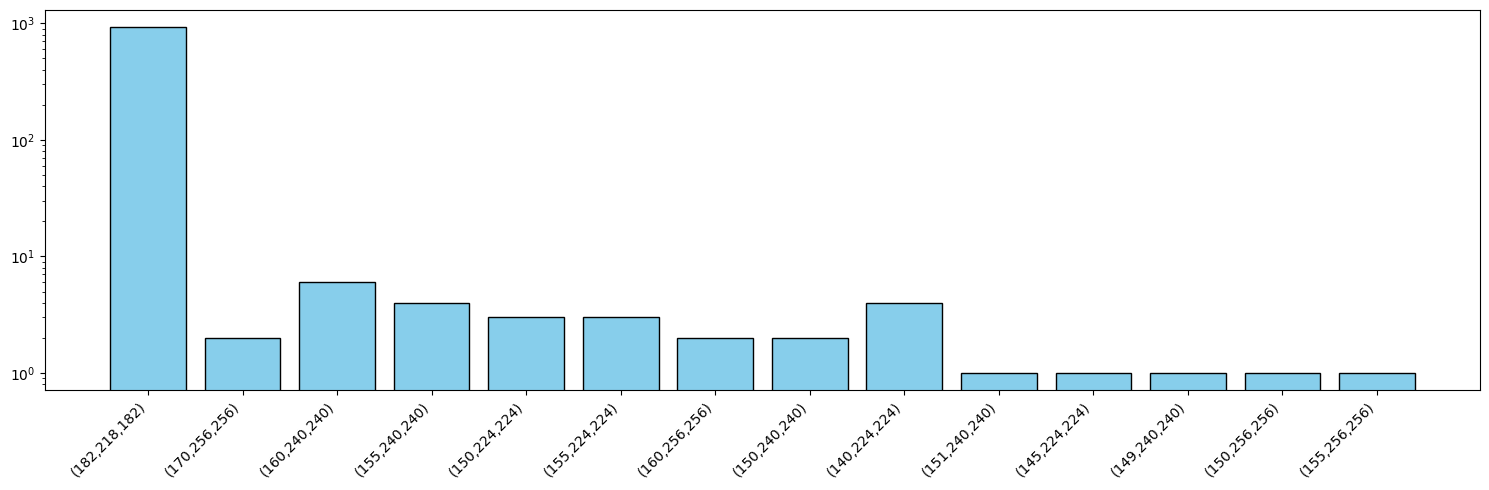

In [6]:
shapes = [
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").shape
    for scans in scans_filepath.values() 
]

counts = Counter(shapes)
fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [23]:
sizes = np.array([
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").header.get_zooms()
    for scans in list(scans_filepath.values())
])

t1_x_mean, t1_x_std = np.mean(sizes[:,0]), np.std(sizes[:,0])
t1_y_mean, t1_y_std = np.mean(sizes[:,1]), np.std(sizes[:,1])
t1_z_mean, t1_z_std = np.mean(sizes[:,2]), np.std(sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.01, 1.00±0.01)


## Orientation

In [31]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").affine))
    for scans in list(scans_filepath.values())
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['LAS', 'RAS'], dtype='<U3'), counts=array([943,  12]))


## C-MIND

In [69]:
subject_id = "0001"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

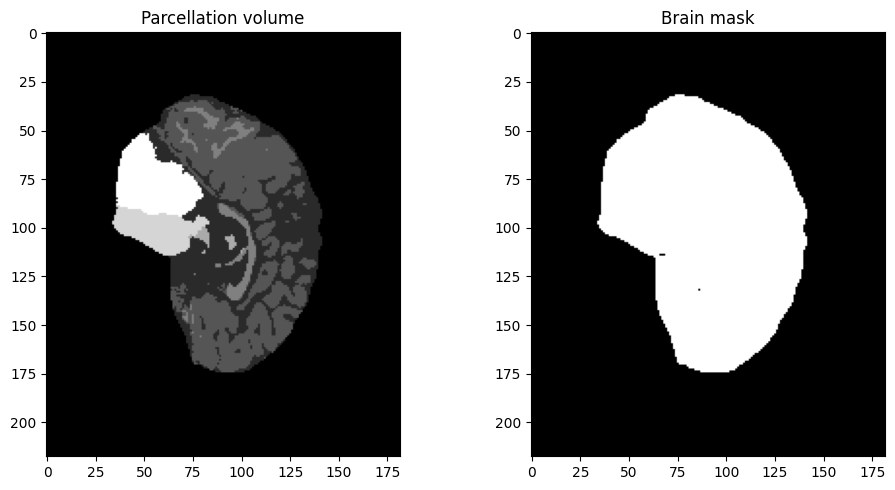

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

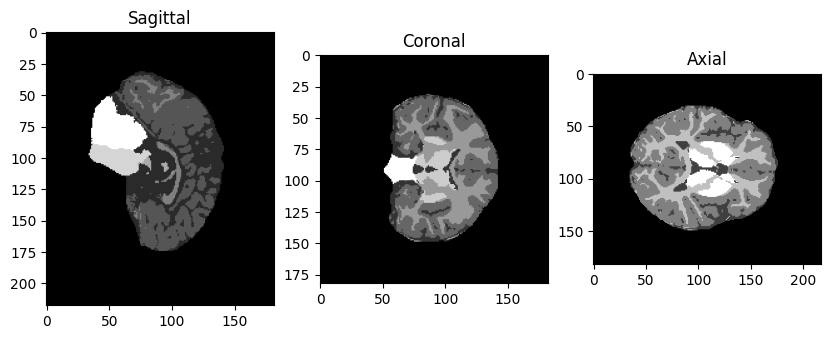

In [71]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

## EMEDEA-PED

In [72]:
subject_id = "0415"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

t1_filepath = scans_filepath[subject_id]["T1-W FILEPATH"]
segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_t1 = nib.load(f"{DBB_DATASET_FOLDER}/{t1_filepath}")
nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

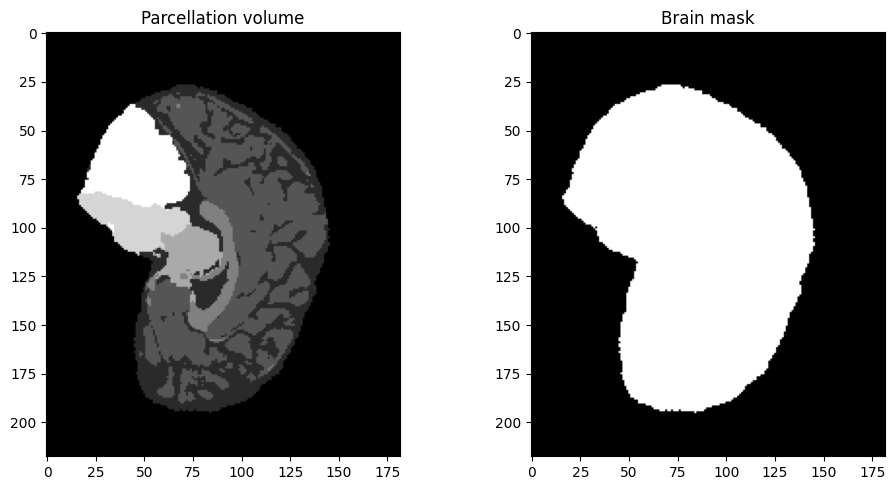

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

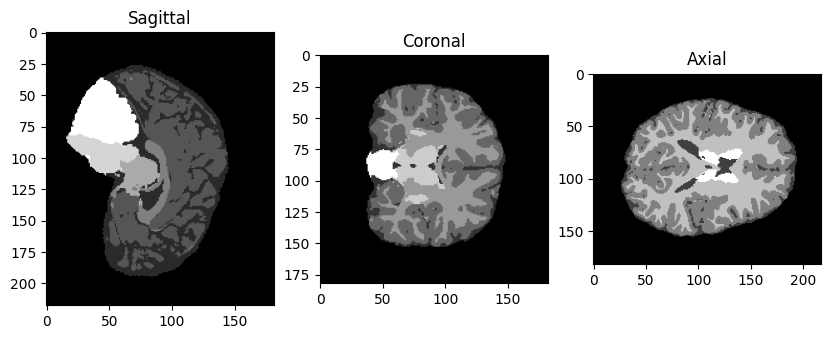

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

## NIH-PED

In [78]:
subject_id = "0519"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

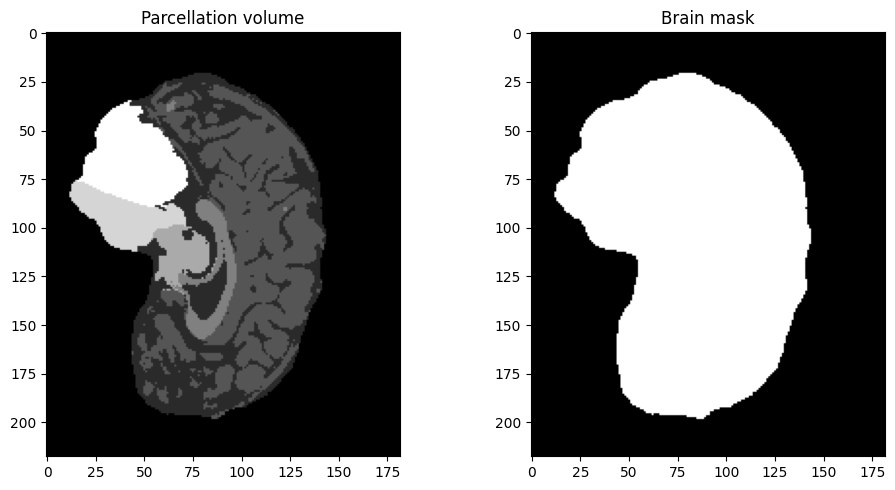

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

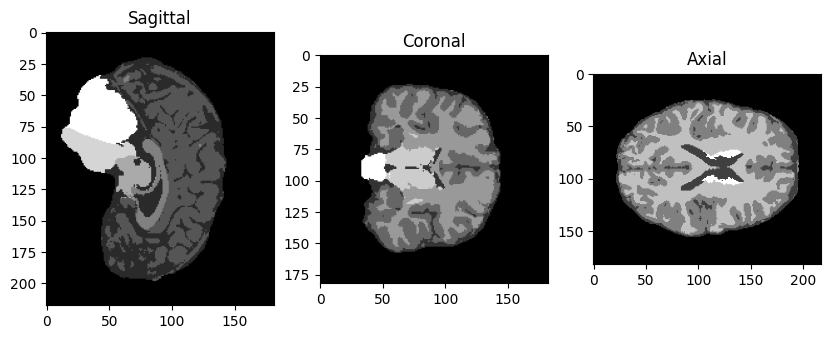

In [80]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

# WMH

## Exploring different centers

In [87]:
whm_dataloader = DataLoader(
    WMH(WMH_DATASET_FOLDER, data_split="training", center="Amsterdam"),
    batch_size=1,
    shuffle=False
)

t1, flair, mask = next(iter(whm_dataloader))
t1 = t1[0,:,:,:]
flair = flair[0,:,:,:]
mask = mask[0,:,:,:]

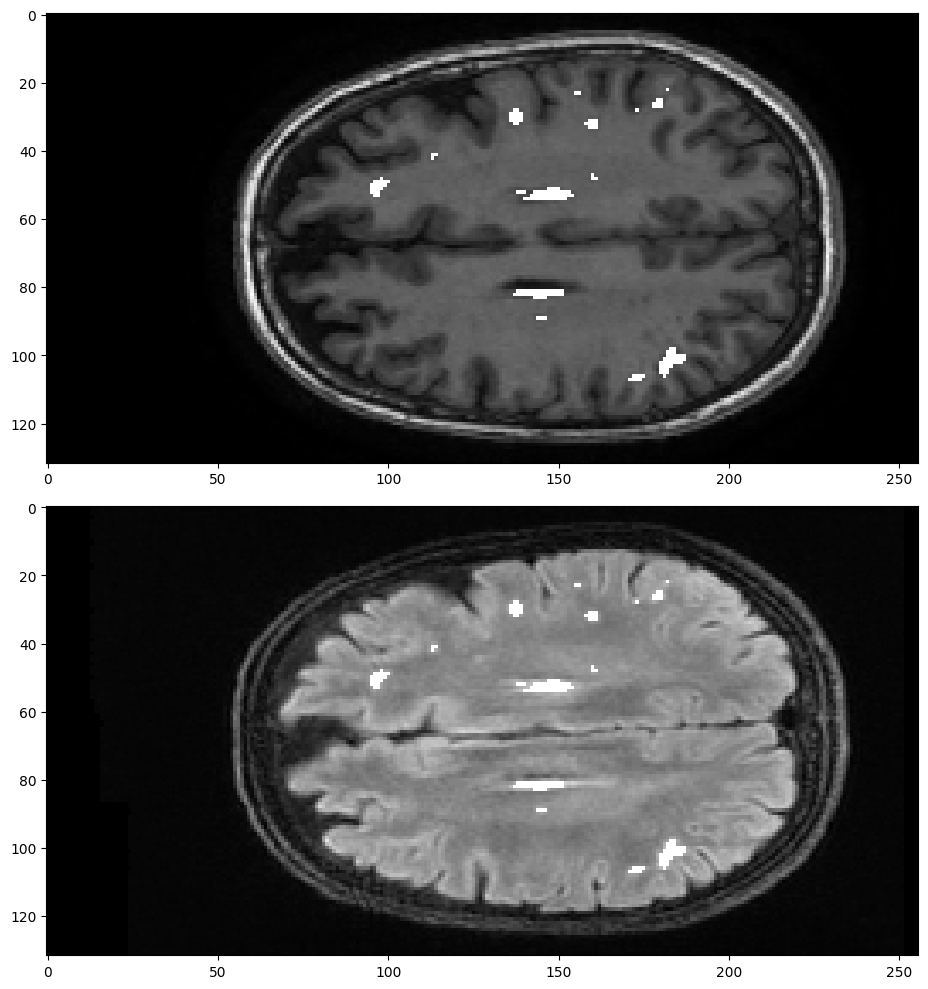

In [88]:
fig, ax = plt.subplots(2,1, figsize=(10,10))

z = 56
ax[0].imshow(t1[:, :, z], cmap=plt.cm.gray)
ax[0].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[1].imshow(flair[:, :, z], cmap=plt.cm.gray)
ax[1].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

plt.tight_layout()

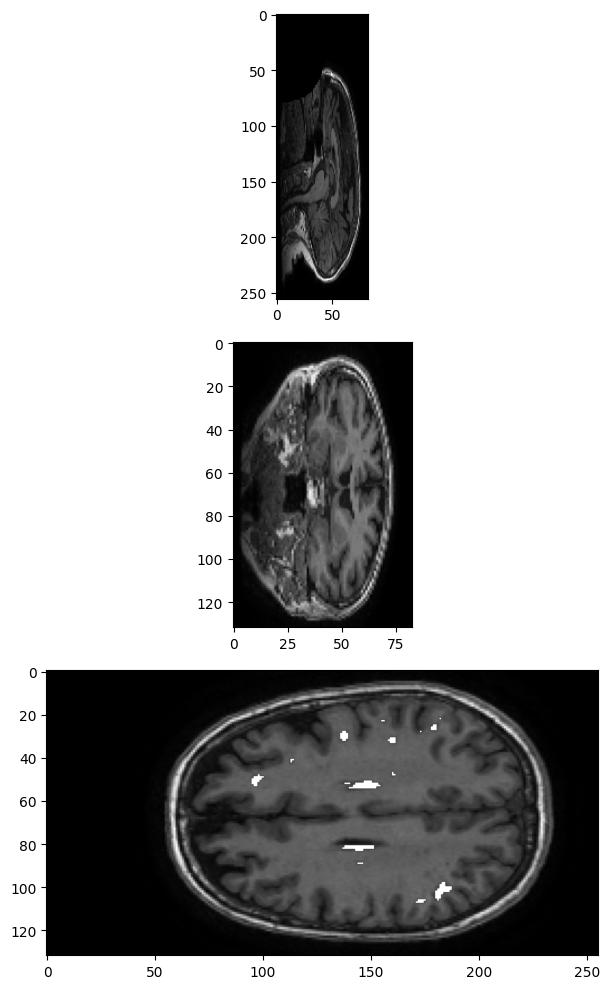

In [92]:
fig, ax = plt.subplots(3,1, figsize=(10,10))

x = 66
ax[0].imshow(t1[x, :, :], cmap=plt.cm.gray)
ax[0].imshow(mask[x, :, :], alpha= (mask[x, :, :] > 0).to(float), cmap=plt.cm.gray)

y = 128
ax[1].imshow(t1[:, y, :], cmap=plt.cm.gray)
ax[1].imshow(mask[:, y, :], alpha= (mask[:, y, :] > 0).to(float), cmap=plt.cm.gray)

z = 56
ax[2].imshow(t1[:, :, z], cmap=plt.cm.gray)
ax[2].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

plt.tight_layout()

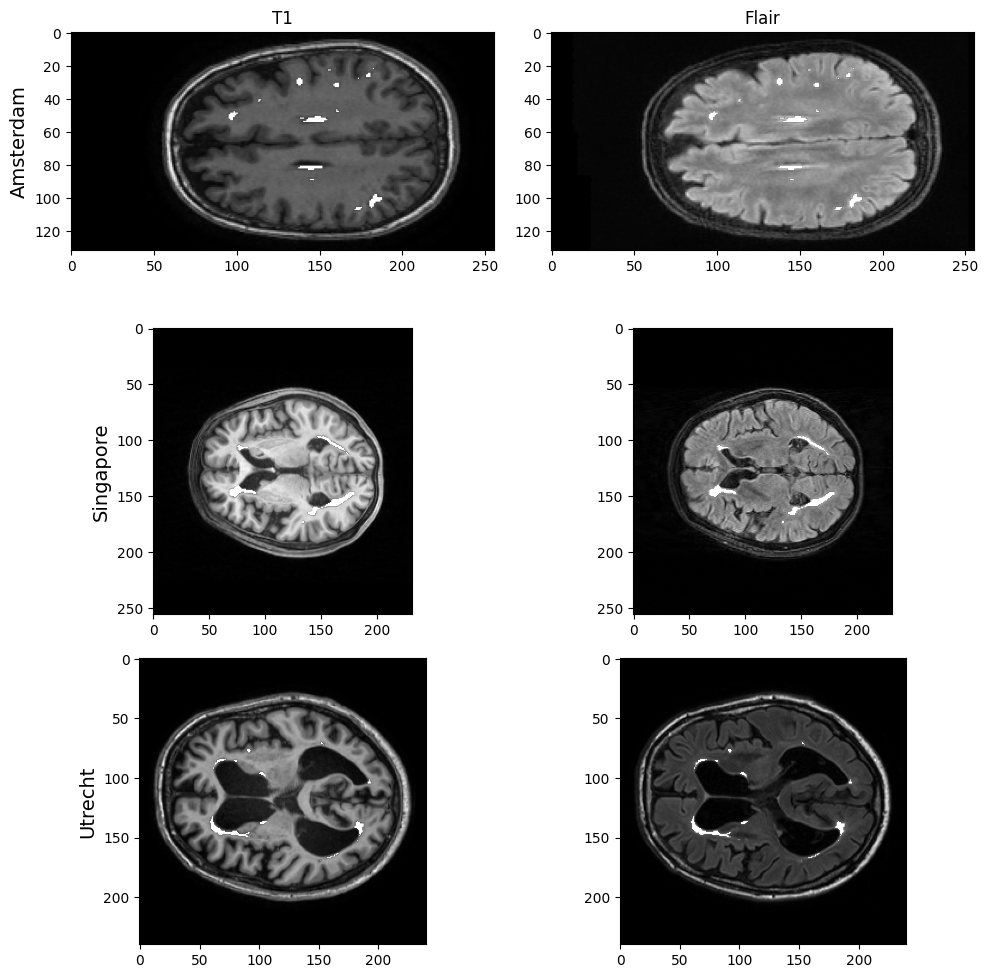

In [86]:
fig, ax = plt.subplots(3,2, figsize=(10,10))

## AMSTERDAM ##
t1, flair, mask = next(iter(DataLoader(WMH(WMH_DATASET_FOLDER, data_split="training", center="Amsterdam"), batch_size=1, shuffle=False)))
t1 = t1[0,:,:,:]
flair = flair[0,:,:,:]
mask = mask[0,:,:,:]
z = 56
ax[0,0].imshow(t1[:, :, z], cmap=plt.cm.gray)
ax[0,0].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[0,1].imshow(flair[:, :, z], cmap=plt.cm.gray)
ax[0,1].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[0,0].set_ylabel("Amsterdam", fontsize=14, rotation=90)
ax[0,0].set_title("T1")
ax[0,1].set_title("Flair")

## SINGAPORE ##
t1, flair, mask = next(iter(DataLoader(WMH(WMH_DATASET_FOLDER, data_split="training", center="Singapore"), batch_size=1, shuffle=False)))
t1 = t1[0,:,:,:]
flair = flair[0,:,:,:]
mask = mask[0,:,:,:]
z = 24
ax[1,0].imshow(t1[:, :, z], cmap=plt.cm.gray)
ax[1,0].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[1,1].imshow(flair[:, :, z], cmap=plt.cm.gray)
ax[1,1].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[1,0].set_ylabel("Singapore", fontsize=14, rotation=90)

## UTRECHT ##
t1, flair, mask = next(iter(DataLoader(WMH(WMH_DATASET_FOLDER, data_split="training", center="Utrecht"), batch_size=1, shuffle=False)))
t1 = t1[0,:,:,:]
flair = flair[0,:,:,:]
mask = mask[0,:,:,:]
z = 24
ax[2,0].imshow(t1[:, :, z], cmap=plt.cm.gray)
ax[2,0].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[2,1].imshow(flair[:, :, z], cmap=plt.cm.gray)
ax[2,1].imshow(mask[:, :, z], alpha= (mask[:, :, z] > 0).to(float), cmap=plt.cm.gray)

ax[2,0].set_ylabel("Utrecht", fontsize=14, rotation=90)

plt.tight_layout()

## Compare image resolutions among the dataset

In [7]:
center_sizes = {
    "Amsterdam": [],
    "Singapore": [],
    "Utrecht": []
}

for center in center_sizes.keys():
    dl = DataLoader(WMH(WMH_DATASET_FOLDER, data_split=None, center=center), batch_size=1, shuffle=False)

    for t1, flair, segmentation in dl:
        t1, flair, segmentation = t1.squeeze(0), flair.squeeze(0), segmentation.squeeze(0) # squeezing batch dimension

        if t1.size() != flair.size() != segmentation.size():
            print("Sizes mismatch")

        center_sizes[center].append(t1.size())

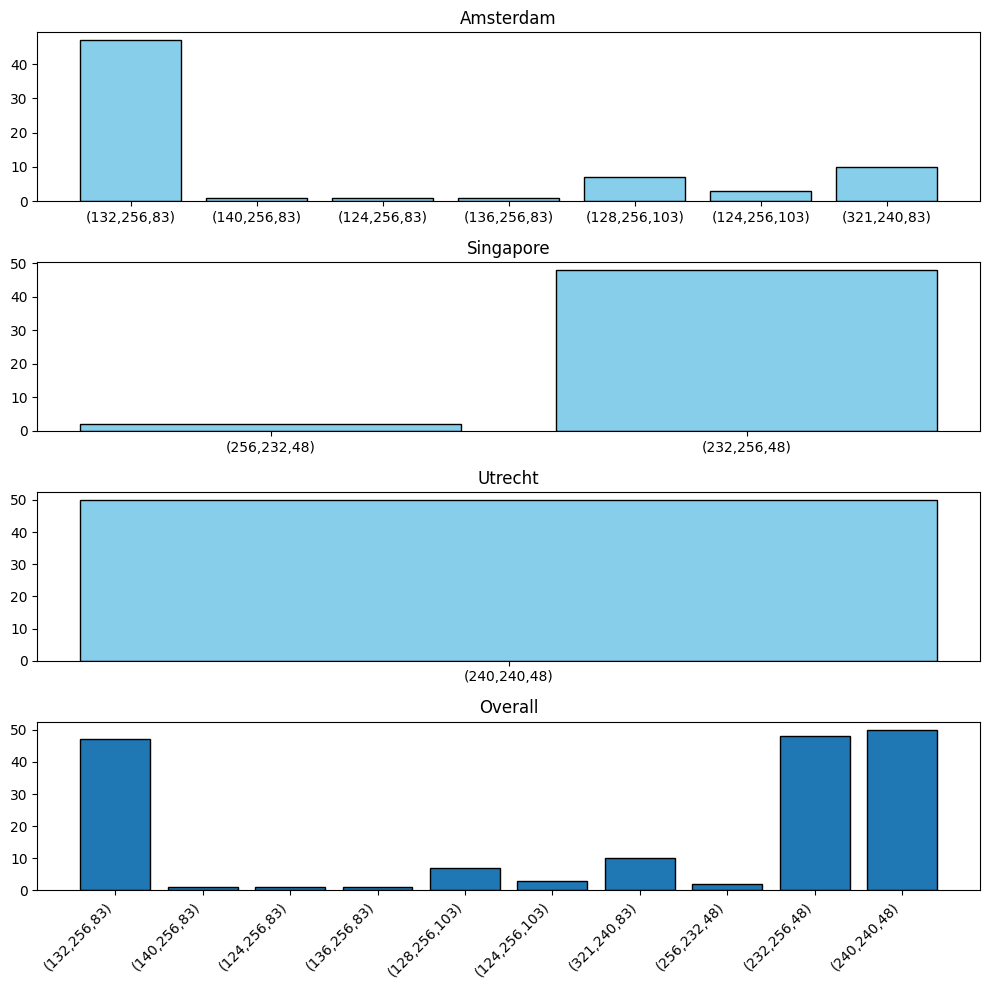

In [6]:
fig, axs = plt.subplots(4, figsize=(10, 10))

center = "Amsterdam"
counts = Counter(center_sizes[center])
axs[0].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[0].set_title(center)

center = "Singapore"
counts = Counter(center_sizes[center])
axs[1].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[1].set_title(center)

center = "Utrecht"
counts = Counter(center_sizes[center])
axs[2].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[2].set_title(center)

counts = Counter(center_sizes["Amsterdam"] + center_sizes["Singapore"] + center_sizes["Utrecht"])
axs[3].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), edgecolor='black')
axs[3].set_title("Overall")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [48]:
center_voxel_sizes = {
    center: {
        "t1": {
            "x": [], 
            "y": [], 
            "z": []
        },
        "flair": {
            "x": [], 
            "y": [], 
            "z": []
        }
    }
    for center in ["Amsterdam", "Singapore", "Utrecht"]
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["t1"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["t1"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["flair"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["flair"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["flair"]["z"].append(z)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["t1"]["x"].append(x)
        center_voxel_sizes["Singapore"]["t1"]["y"].append(y)
        center_voxel_sizes["Singapore"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["flair"]["x"].append(x)
        center_voxel_sizes["Singapore"]["flair"]["y"].append(y)
        center_voxel_sizes["Singapore"]["flair"]["z"].append(z)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["t1"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["t1"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["flair"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["flair"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["flair"]["z"].append(z)

In [49]:
for center in ["Amsterdam", "Singapore", "Utrecht"]:
    print(f"-- {center} --")
    t1_x_mean, t1_x_std = np.mean(center_voxel_sizes[center]["t1"]["x"]), np.std(center_voxel_sizes[center]["t1"]["x"])
    t1_y_mean, t1_y_std = np.mean(center_voxel_sizes[center]["t1"]["y"]), np.std(center_voxel_sizes[center]["t1"]["y"])
    t1_z_mean, t1_z_std = np.mean(center_voxel_sizes[center]["t1"]["z"]), np.std(center_voxel_sizes[center]["t1"]["z"])
    
    flair_x_mean, flair_x_std = np.mean(center_voxel_sizes[center]["flair"]["x"]), np.std(center_voxel_sizes[center]["flair"]["x"])
    flair_y_mean, flair_y_std = np.mean(center_voxel_sizes[center]["flair"]["y"]), np.std(center_voxel_sizes[center]["flair"]["y"])
    flair_z_mean, flair_z_std = np.mean(center_voxel_sizes[center]["flair"]["z"]), np.std(center_voxel_sizes[center]["flair"]["z"])
    
    print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")
    print(f"[FLAIR] ({flair_x_mean:.2f}±{flair_x_std:.2f}, {flair_y_mean:.2f}±{flair_y_std:.2f}, {flair_z_mean:.2f}±{flair_z_std:.2f})")

    print()

-- Amsterdam --
[T1] (1.12±0.23, 1.02±0.08, 3.00±0.00)
[FLAIR] (1.12±0.23, 1.02±0.08, 3.00±0.00)

-- Singapore --
[T1] (1.00±0.00, 1.00±0.00, 3.00±0.00)
[FLAIR] (1.00±0.00, 1.00±0.00, 3.00±0.00)

-- Utrecht --
[T1] (0.96±0.00, 0.96±0.00, 3.00±0.00)
[FLAIR] (0.96±0.00, 0.96±0.00, 3.00±0.00)



## Orientation

https://stackoverflow.com/questions/66231763/how-to-check-nifti-image-is-in-the-right-orientation-position-with-python

In [67]:
orientations = {
    "t1": [],
    "flair": []
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

In [76]:
print(np.unique_counts(orientations["t1"]))
print(np.unique_counts(orientations["flair"]))

UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))
UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))


In [59]:
# conversion to RAS
img_ras = nib.as_closest_canonical(img)
print(nib.aff2axcodes(img_ras.affine))

('R', 'A', 'S')
